## Esame di Metodi Numerici

21 Luglio 2023

# Esercizio 1
Nel file ``testI.mat`` sono memorizzati la matrice A ed il vettore b. 

 - Verificare che per risolvere il sistema Ax=b sia possibile utilizzare i due metodi di discesa visti a lezione, **Punti 1**
 - implementare entrambi gli algoritmi e dire quante iterazioni sono necessarie per ciascuno di essi  per calcolare la soluzione con una toll=1e-6 e maxit=2000. Visualizzare in un grafico l'errore in scala logaritmica ad ogni iterazione per ciascuno dei due metodi. **Punti 6**
 - Verificare se la matrice è  malcondizionata, dire teoricamente cosa questo implica in termini della velocità di convergenza  dei due metodi alla soluzione, richiamando il risultato teorico visto a lezione.**Punti 2**

 - Costruire la matrice A1, ottenuta a partire da A, sommandole uma matrice diagonale con elementi sulla diagonali tutti uguali a 0.05, e termine noto b1, costruito in maniera tale che la soluzione del sistema A1 x1 =b1 sia il vettore formato da tutti 1. Risolvere il sistema lineare con matrice dei coefficienti A1 e termine noto b1, sia con il metodo del gradiente che con il metodo del gradiente coniugato. Osservare il numero di iterazioni eseguito da ciascun metodo e giustificare i risultati  **Punti 2**
  
   **Totale: Punti 11**

Per la lettura dei dati procedere nel seguente modo:

``from scipy.io import loadmat``

``import numpy as np``

``dati = loadmat('testI.mat')``

``A=dati["A"] ``

``A=A.astype(float)``

`` b=dati["b"] ``

`` b=b.astype(float)``



Numero di iterazioni di steepest descent → 2002

Numero di iterazioni di gradente congniugato → 327


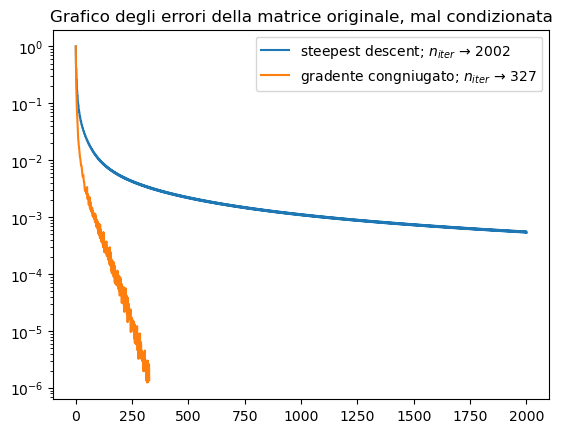

Condizionamento di A → 10000.000000004271
Condizionamento di A (Matrice perturbata) → 20.958083832335376

Numero di iterazioni di steepest descent → 254

Numero di iterazioni di gradente congnugato → 31


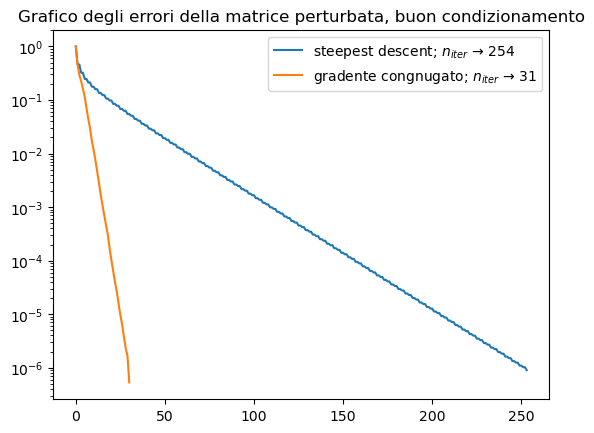

In [1]:
from scipy.io import loadmat
import numpy as np
import numpy.linalg as lin
import scipy.linalg as splin
import matplotlib.pyplot as plt
from itertools import takewhile
from numpy.linalg import norm

dati = loadmat('testI.mat')
A=dati["A"]
A=A.astype(float)
b=dati["b"]
b=b.astype(float).ravel()

#Punto 1, la matrice è simmetrica e semidefinita positiva dunque è possibile applicare i metodi +
# di discesa

assert(splin.issymmetric(A))
assert(splin.ishermitian(A))

#Punto 2, utilizziamo un unico metodo scheletro per applicare i metodi di discesa
#differiscono per la costruzione del'alfa scalare e la direzione del prossimo piano ellittico 
#sulla quale andare a scegliere la x desiderata

def iterate(func, start):
    while True:
        yield start
        start = func(*start)
        
def steep(A, b, dir, alfa, toll=1e-6, itmax=2000):
    x0 = np.zeros_like(b)
    r = A @ x0 - b
    err = lambda num, den: norm(num)/norm(den)

    def passo(x, r, p):
        a = alfa(A, r, p)
        nr = r + a*(A @ p)
        return x + a*p, nr, dir(nr, r, p)

    stop_criteria = lambda i, args: i <= itmax and err(args[1], b) >= toll
    iter = iterate(passo, (x0, r, -r))
    arr = list(dict(takewhile(lambda param: stop_criteria(*param), enumerate(iter))).values()) + [next(iter)]

    x_arr = [x for x, r, p in arr]
    return x_arr[-1], len(x_arr), [err(r, b) for x, r, p in arr]


def steepest(A, b):
    alfa = lambda A, r, p: -r.T @ p / (A.T @ p @ p)
    dir = lambda nr, r, p: -r
    return steep(A, b, dir, alfa)

def conj(A, b):
    alfa = lambda A, r, p: -r.T @ p / (A.T @ p @ p)
    def dir (nr, r, p):
        gamma = (nr.T @ nr) / (r.T @ r)
        return -nr + (gamma * p)
    return steep(A, b, dir, alfa)

def plot_graph(A, b, method, name):
    _, it, err = method(A, b)
    plt.semilogy(range(it), err, label=name + r'; $n_{iter}$ → '+f'{it}')
    print(f'\nNumero di iterazioni di {name} → {it}')
    
plot_graph(A, b, steepest, 'steepest descent')
plot_graph(A, b, conj, 'gradente congniugato')
plt.title('Grafico degli errori della matrice originale, mal condizionata')
plt.legend()
plt.show()

#Punto 3 matrice mal condizionata, infatti la soluzione data dai metodi differisce 
#rispetto alla reale soluzione ed entrambi i metodi impiegano un gran numero di iterazioni
#Addirittura il primo metodo non converge alla soluzione rispettando la tolleranza fornita, 
#mentre il gradiente cogniugato si, questo perchè nel calcolare la prossima direzione impiega meno 
#moltiplicazioni, convergendo piu ripidamente e con un minor numero di iterazioni
print(f'Condizionamento di A → {lin.cond(A)}')

#Perturbiamo la matrice iniziale
A += np.diag(np.zeros_like(b) + 0.05)
b = A @ np.ones_like(b)


print(f'Condizionamento di A (Matrice perturbata) → {lin.cond(A)}')
plot_graph(A, b, steepest, 'steepest descent')
plot_graph(A, b, conj, 'gradente congnugato')
plt.legend()
plt.title('Grafico degli errori della matrice perturbata, buon condizionamento')
plt.show()

# Esercizio 2

Siano assegnati i vettori
$$
x = [1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0] , $$
$$
y = [1.18, 1.26, 1.23, 1.37, 1.37, 1.45, 1.42, 1.46, 1.53, 1.59, 1.59] 
$$

contenenti rispettivamente le ascisse e le ordinate di 11 punti del piano.

Scrivere lo script  in cui
 - si determini il polinomio di approssimazione ai minimi quadrati di grado 1 dei  punti assegnati sviluppando  le functions necessarie; **Punti: 4**
- si determini il polinomio di interpolazione dei punti assegnati sviluppando le functions necessarie;  **Punti: 4**
- si consideri il set di dati ($x_i,\hat{y}_i$) , dove $\hat{y}_i = 0.2 x_i+1$, $i = 0, ..., 10$ e si ricalcolino il polinomio di approssimazione ai minimi quadrati di grado 1 e il polinomio di interpolazione a partire dai nuovi punti $(x_i, \hat{y}_i)$, i = 0, ..., 10; **Punti: 1**
- si rappresentino in figura 1 (rispettivamente in figura 2) il primo (rispettivamente il secondo) set di punti assegnato insieme al polinomio di approssimazione ai minimi quadrati e al polinomio di interpolazione ottenuti da questi dati; **Punti: 1**
- si fornisca una spiegazione teorica ai risultati ottenuti, utilizzando i teoremi visti a lezione.   **Punti: 4**

**Totale:  14**

Condizionamento di G → 70.88589282069798



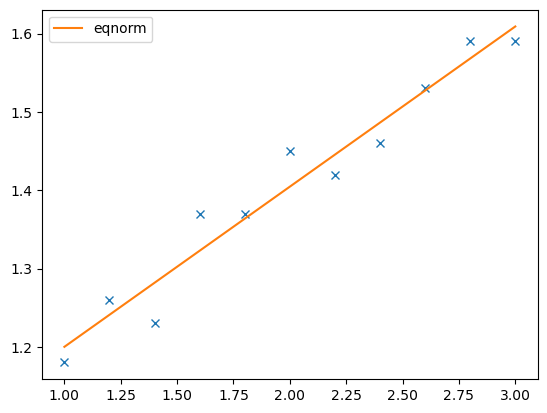

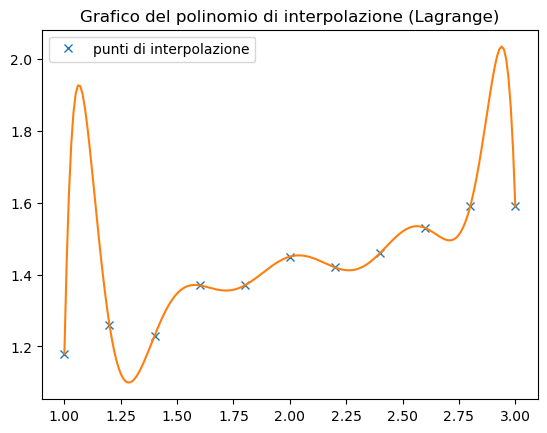

Altro set di dati


Condizionamento di R → 11.295670078751836

Residuo (norma 2) → 1.0107280348144216e-30


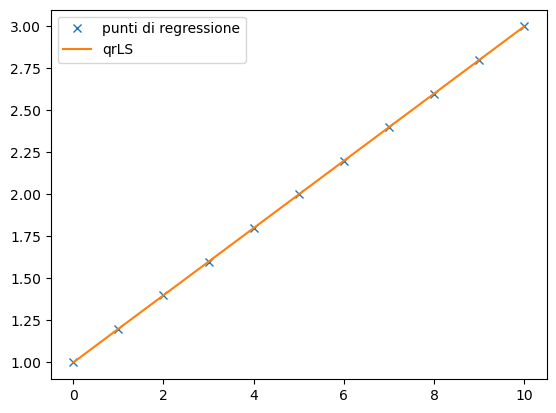

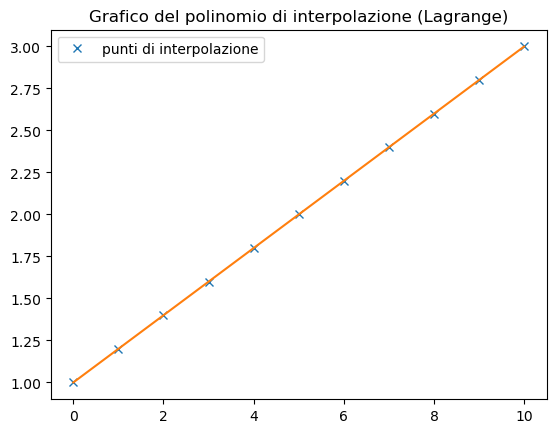

In [9]:
from RisolviSis import *
from numpy.linalg import matrix_rank as rank

x = np.array([1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0])
y = np.array([1.18, 1.26, 1.23, 1.37, 1.37, 1.45, 1.42, 1.46, 1.53, 1.59, 1.59])

plt.plot(x, y, 'x')
xv = np.linspace(min(x), max(x), 200)

#Punto 1: Usiamo la matrice di vander di grado 1
n = 1
A = np.vander(x, increasing=True)[:,0:n+1]
print(f'Condizionamento di G → {lin.cond(A.T @ A)}\n')
#Condizionamento buono usiamo il metodo delle equazioni normali

def cholensky_solve(A, b):
    L = lin.cholesky(A)
    return Usolve(L.T, Lsolve(L, b))

    
def eqnorm(A, b):
    m, n = A.shape
    if rank(A) < n:
        print('Matrice non ha il rango massimo')
    G = A.T @ A
    return cholensky_solve(G, A.T @ b)

def qrLS(A, b):
    Q, R = splin.qr(A)
    R1 = R[:rank(A)]
    h = Q.T @ b
    h1 = h[:rank(A)]
    print(f'Condizionamento di R → {lin.cond(R)}\n')
    print(f"Residuo (norma 2) → {norm(h[rank(A):])**2}")
    return Usolve(R1, h1)

def plot_regression(x, y, xv, method, A, name):
    coef = method(A, y)
    plt.plot(xv, np.polyval(np.flip(coef), xv), label=name)

plot_regression(x, y, xv, eqnorm, A, 'eqnorm')

plt.legend()
plt.show()

#Punto 2 Interpolazione
def lagrange(xnodi, j):
    x = xnodi[xnodi != xnodi[j]]
    num = np.poly(x)
    den = np.polyval(num, xnodi[j])
    return num / den

def interL(x, y, xv):
    L = np.array([np.polyval(lagrange(x, j), xv) for j, v in enumerate(x)])
    return L.T @ y

plt.plot(x, y, 'x', label='punti di interpolazione')
plt.plot(xv, interL(x, y, xv))
plt.title('Grafico del polinomio di interpolazione (Lagrange)')
plt.legend()
plt.show()

#Punto 3
#perturbiamo il set di dati
xi = np.arange(0,11)
y = .2 * xi + 1
xv = np.linspace(min(xi), max(xi), 200)

print('Altro set di dati\n\n')
A = np.vander(xi, increasing=True)[:,0:n+1]
plt.plot(xi, y, 'x', label='punti di regressione')
plot_regression(xi, y, xv, qrLS, A, 'qrLS')
plt.legend()
plt.show()

plt.plot(xi, y, 'x', label='punti di interpolazione')
plt.plot(xv, interL(xi, y, xv))
plt.title('Grafico del polinomio di interpolazione (Lagrange)')
plt.legend()
plt.show()


contenenti## Domanda intelligenza artificiale

- Allenamento di una rete neurale: dopo aver descritto come è composta una rete neurale, descrivi in cosa consiste la fase di forward propagation e la fase di backward propagation. **Punti: 1**
- Ottimizzazione della loss function per il training di una rete neurale per il task di regressione: Metodo di discesa del gradiente, metodo stocastico del gradiente, metodo del gradiente minibatch.  **Punti 1**  
 - Non convessità della loss-function - come non rimanere bloccati in un monimo locale? Metodo del gradiente con momentum. **Punti 2**
- Learning rate scheduling: step decay, decadimento esponenziale, decadimento dipendente dal tempo. **Punti 1**
 - Learning rate adattivo: Adagrad, RMSProp, Adadelta, Adam. **Punti 2**
 
 **Totale:  7**